In [2]:
!pip install hvplot pygwalker panel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 50.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 64.1 MB/s eta 0:00:00:00:0100:01


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krupalpatel07/nvidia-historical-data/NVDA.csv


In [3]:
import plotly.graph_objects as go
import plotly.express as px

import hvplot.pandas
import seaborn as sns
import panel as pn

import pygwalker as pyg
from IPython.display import display, HTML

/usr/local/lib/python3.12/dist-packages/mistune.py:435: SyntaxWarning: invalid escape sequence '\|'
  cells[i][c] = re.sub('\\\\\|', '|', cell)
/usr/local/lib/python3.12/dist-packages/nbconvert/filters/filter_links.py:36: SyntaxWarning: invalid escape sequence '\_'
  text = re.sub(r'_', '\_', text) # Escape underscores in display text


In [4]:
HTML("""
<style>

.dashboard {
background: linear-gradient(135deg,#0f172a,#1e293b);
padding:40px;
border-radius:15px;
color:white;
font-family:Arial;
}

.title {
font-size:40px;
font-weight:700;
}

.subtitle {
font-size:18px;
color:#94a3b8;
}

.metric-box{
display:inline-block;
background:#111827;
padding:15px;
margin:10px;
border-radius:10px;
width:200px;
text-align:center;
}

.metric-number{
font-size:24px;
font-weight:bold;
color:#22c55e;
}

</style>

<div class="dashboard">
<div class="title">NVIDIA Research Lab</div>
<div class="subtitle">Deep Exploration of NVDA Market Structure (1999-Present)</div>
</div>

""")

In [31]:
df = pd.read_csv('/kaggle/input/datasets/krupalpatel07/nvidia-historical-data/NVDA.csv')

In [32]:
df["returns"] = df["Close"].pct_change()

df["volatility"] = df["returns"].rolling(30).std()

df["volume_ma"] = df["Volume"].rolling(50).mean()

df["momentum"] = df["Close"].pct_change(90)

df["drawdown"] = df["Close"] / df["Close"].cummax() - 1

df = df.dropna()

In [33]:
df['Date'] = pd.to_datetime(df['Date']).dt.date

In [34]:
df['month'] = pd.to_datetime(df['Date']).dt.month
df['year'] = pd.to_datetime(df['Date']).dt.year

In [36]:
df.set_index("Date",inplace = True)

In [42]:
pyg.walk(df)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064c7bd9c8f512R1cs8uzeJ9rlwkHj" style="height: auto">\n    <hea…

In [28]:
fig = go.Figure()

fig.add_trace(go.Candlestick(
    x=df.index,
    open=df["Open"],
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    name="Price"
))

fig.update_layout(
title="NVIDIA OHLCV Market Structure",
template="plotly_dark",
height=600
)

fig.show()

In [29]:
fig = px.line(
df,
y="volatility",
title="Rolling Volatility Regime (30 Day)",
template="plotly_dark"
)

fig.show()

This shows market stress periods:

* dotcom crash

* financial crisis

* covid crash

* AI boom

<Axes: xlabel='year', ylabel='month'>

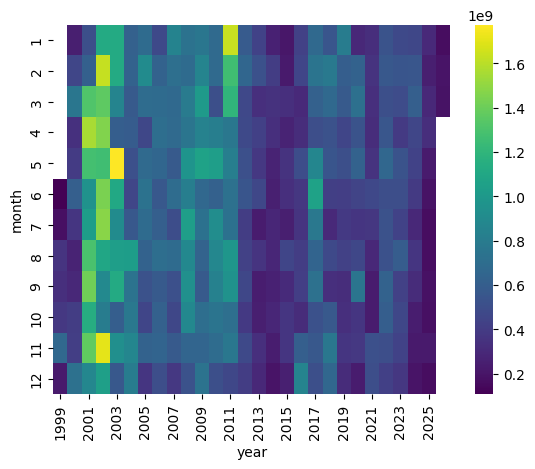

In [37]:
pivot = df.pivot_table(
values="Volume",
index="month",
columns="year"
)

sns.heatmap(pivot,cmap="viridis")

In [38]:
fig = px.area(
df,
y="drawdown",
title="Maximum Drawdown Cycles",
template="plotly_dark"
)

fig.show()

In [39]:
df.hvplot(
y=["Close","volume_ma"],
shared_axes=False,
height=400,
title="Price vs Volume Flow")

:NdOverlay   [Variable]
   :Curve   [Date]   (value)

In [40]:
df["alpha_signal"] = df["momentum"] - df["volatility"]

fig = px.scatter(
df,
x="alpha_signal",
y="returns",
color="volatility",
title="Alpha Signal vs Returns",
template="plotly_dark"
)

fig.show()

In [43]:
sharpe = np.sqrt(252)*df["returns"].mean()/df["returns"].std()

max_dd = df["drawdown"].min()

print("Sharpe Ratio:",sharpe)
print("Max Drawdown:",max_dd)

Sharpe Ratio: 0.837227270055568
Max Drawdown: -0.8972243014806714


In [44]:
price_plot = df.hvplot.line(
y="Close",
title="NVIDIA Price History"
)

vol_plot = df.hvplot.line(
y="volatility",
title="Volatility Regime"
)

dashboard = pn.Column(
"# NVIDIA Dashboard",
price_plot,
vol_plot
)

dashboard

Column
    [0] Markdown(str)
    [1] HoloViews(Curve, height=300, sizing_mode='fixed', width=700)
    [2] HoloViews(Curve, height=300, sizing_mode='fixed', width=700)